In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd

In [ ]:
# Define the dataset
class MyDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MLM")

In [5]:
# Load the data

resp = pd.read_csv("AID_1224879_datatable_hepg2_40h.csv", skiprows=range(1,6))
resp = resp.dropna(subset=["PUBCHEM_EXT_DATASOURCE_SMILES"])
resp

/tmp/ipykernel_65646/356711018.py:3: DtypeWarning: Columns (49,54,61,89,94,101,129,134,141,169,174,181,209,214,221,249,254,261,289,294,301,329,334,341,369,374,381,409,414,421,449,454,461,489,494,501,529,534,541,569,574,581,609,614,621,649,654,661) have mixed types. Specify dtype option on import or set low_memory=False.
  resp = pd.read_csv("AID_1224879_datatable_hepg2_40h.csv", skiprows=range(1,6))


,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Phenotype-Replicate_1,Potency-Replicate_1,...,Activity at 15.76 uM-Replicate_17,Activity at 35.30 uM-Replicate_17,Activity at 76.83 uM-Replicate_17,Activity at 199.8 uM-Replicate_17,Activity at 725.3 uM-Replicate_17,Activity at 1537.0 uM-Replicate_17,Activity at 3438.0 uM-Replicate_17,Activity at 7687.0 uM-Replicate_17,Activity at 17190.0 uM-Replicate_17,Activity at 38440.0 uM-Replicate_17
0,1,144205501,17931.0,CN1C(=S)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,144206117,3045407.0,CO[C@H]1[C@@H](C[C@@H]2CN3CCC4=C([C@H]3C[C@@H]...,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,144206325,14708.0,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C)O)CC[C@@...,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,144206326,3085168.0,CC1=NC=C(C(=N1)N)CN(C=O)/C(=C(\CCO)/SS/C(=C(/C...,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,144206328,54158.0,CC1=CC(=C(C(=C1NC(=O)CN(CC(=O)O)CC(=O)O)C)Br)C,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9661,9662,251919986,47364.0,C[As+](C)(C)CC(=O)[O-],Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9662,9663,251919987,23664984.0,CCC1=C(C(=CC=C1)CC)N(COC)C(=O)CS(=O)(=O)[O-].[...,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9663,9664,251919988,2724429.0,CCCC(C(CO)O)O,Inactive,0,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9664,9665,251919989,13059052.0,CC(C)(C1=CC(=C(C=C1)O)C2=CC=CC=C2)C3=CC(=C(C=C...,Active,42,http://assay.nih.gov/htsws/rest/display/tox21-...,NaN,Activator,48.9662,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
resp['Class'] = resp['PUBCHEM_ACTIVITY_OUTCOME'].apply(lambda x: 1 if x =='Active' else 0)

In [7]:
from sklearn.model_selection import train_test_split

train_smiles, val_smiles, train_labels, val_labels = train_test_split(resp.PUBCHEM_EXT_DATASOURCE_SMILES.values,
                                                                      resp.Class.values,
                                                                      test_size=0.2,
                                                                      stratify=resp.Class.values,
                                                                      random_state=42)

In [8]:
train_smiles = list(train_smiles)
val_smiles = list(val_smiles)

In [9]:
# Tokenize the training and validation data
train_encodings = tokenizer(train_smiles, truncation=True, padding=True)
val_encodings = tokenizer(val_smiles, truncation=True, padding=True)

In [10]:
# Create training and validation datasets
train_dataset = MyDataset(train_encodings, train_labels)
val_dataset = MyDataset(val_encodings, val_labels)

In [ ]:
# Load the pre-trained ChemBERTa model with a classification head
model = AutoModelForSequenceClassification.from_pretrained("DeepChem/ChemBERTa-77M-MLM",
                                                           num_labels=2)

In [12]:
device = torch.device("cuda")
model.to(device)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(600, 384, padding_idx=1)
      (position_embeddings): Embedding(515, 384, padding_idx=1)
      (token_type_embeddings): Embedding(1, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.144, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.109, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
             

In [13]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./liver_results',          # Output directory
    num_train_epochs=200,              # Total number of training epochs
    per_device_train_batch_size=64,   # Batch size per device during training
    per_device_eval_batch_size=64,
    warmup_steps=500,                # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # Strength of weight decay
    logging_dir='./liver_logs',            # Directory for storing logs
    evaluation_strategy="steps", optim="adamw_torch", learning_rate=0.00001

)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [14]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, predictions),
           'binary_cross_entropy': log_loss(labels, logits)
           }

In [15]:
# Update the Trainer initialization to include validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

/people/shou626/.conda/envs/huggingface_mixtures/lib/python3.9/site-packages/accelerate/accelerator.py:457: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None)
  warnings.warn(
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [16]:
# initial evaluation

trainer.evaluate()

/people/shou626/.conda/envs/huggingface_mixtures/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/people/shou626/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2969: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(


{'eval_loss': 0.6787046790122986,
 'eval_accuracy': 0.7506561679790026,
 'eval_binary_cross_entropy': 1.6919022835463795,
 'eval_runtime': 4.2157,
 'eval_samples_per_second': 451.887,
 'eval_steps_per_second': 0.949}

In [17]:
trainer.state.log_history

[{'eval_loss': 0.6787046790122986,
  'eval_accuracy': 0.7506561679790026,
  'eval_binary_cross_entropy': 1.6919022835463795,
  'eval_runtime': 4.2157,
  'eval_samples_per_second': 451.887,
  'eval_steps_per_second': 0.949,
  'step': 0}]

In [18]:
# train

trainer.train()

/people/shou626/.conda/envs/huggingface_mixtures/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy,Binary Cross Entropy
500,0.499300,0.326055,0.892913,1.690727
1000,0.300000,0.291986,0.893438,1.568595
1500,0.268700,0.285989,0.892913,1.599376
2000,0.252500,0.289450,0.890289,1.635955
2500,0.242300,0.289510,0.891864,1.611267
3000,0.238900,0.291066,0.888189,1.659232


/people/shou626/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2969: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/people/shou626/.conda/envs/huggingface_mixtures/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/people/shou626/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2969: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/people/shou626/.conda/envs/huggingface_mixtures/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/people/shou626/.local/lib/python3.9/site-packages/sklearn/metri

TrainOutput(global_step=3000, training_loss=0.30029573567708334, metrics={'train_runtime': 413.9977, 'train_samples_per_second': 3680.697, 'train_steps_per_second': 7.246, 'total_flos': 5704472031398400.0, 'train_loss': 0.30029573567708334, 'epoch': 200.0})

In [19]:
pd.DataFrame(trainer.state.log_history)

,loss,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_binary_cross_entropy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.4993,0.000010,33.33,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,33.33,500,0.326055,0.892913,1.690727,0.4174,4563.672,9.583,NaN,NaN,NaN,NaN,NaN
2,0.3000,0.000008,66.67,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,66.67,1000,0.291986,0.893438,1.568595,0.5844,3259.640,6.844,NaN,NaN,NaN,NaN,NaN
4,0.2687,0.000006,100.00,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,100.00,1500,0.285989,0.892913,1.599376,0.3890,4897.386,10.283,NaN,NaN,NaN,NaN,NaN
6,0.2525,0.000004,133.33,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,133.33,2000,0.289450,0.890289,1.635955,0.3919,4861.152,10.207,NaN,NaN,NaN,NaN,NaN
8,0.2423,0.000002,166.67,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,166.67,2500,0.289510,0.891864,1.611267,0.3927,4850.890,10.186,NaN,NaN,NaN,NaN,NaN


In [20]:
# final evaluation

trainer.evaluate()

/people/shou626/.conda/envs/huggingface_mixtures/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/people/shou626/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2969: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(


{'eval_loss': 0.2910664975643158,
 'eval_accuracy': 0.8881889763779528,
 'eval_binary_cross_entropy': 1.659231716672422,
 'eval_runtime': 0.3934,
 'eval_samples_per_second': 4842.567,
 'eval_steps_per_second': 10.168,
 'epoch': 200.0}

# Make predictions

In [ ]:
predictions = trainer.predict(val_dataset)

probabilities = torch.softmax(torch.tensor(predictions.predictions), dim=-1)

predicted_labels = np.argmax(probabilities, axis=-1)

actual_labels = np.array(val_dataset.labels)

# Construct Confusion matrix

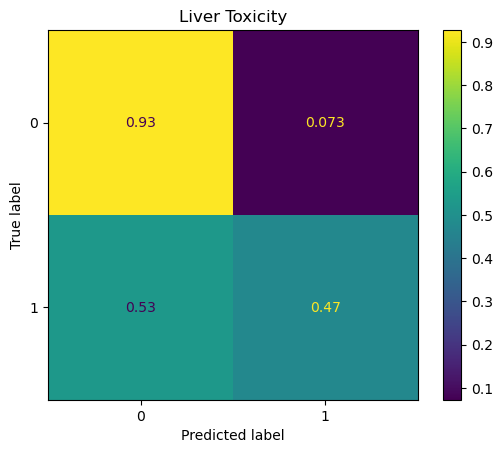

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(predicted_labels, actual_labels, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Liver Toxicity")
plt.savefig("chemberta_pubchem_tox.png")
plt.show()

In [23]:
accuracy_score(predicted_labels, actual_labels)

0.8881889763779528

In [24]:
import sklearn

sklearn.metrics.roc_auc_score(predicted_labels, actual_labels)

0.6997439654018722

In [25]:
sklearn.metrics.precision_score(predicted_labels, actual_labels)

0.37745098039215685

In [26]:
sklearn.metrics.recall_score(predicted_labels, actual_labels)

0.4723926380368098

In [28]:
fpr, tpr, threshold = sklearn.metrics.roc_curve(predicted_labels, actual_labels)
roc_auc = sklearn.metrics.auc(fpr, tpr)

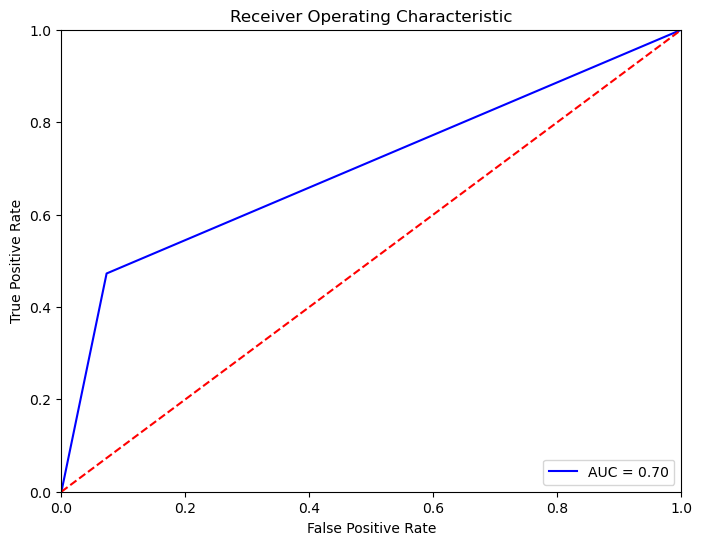

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig("chemberta_pubchem_ROC.png", dpi=400)
plt.show()

# Save model

In [30]:
model_save_path = "./livertox/"

In [31]:
# save model
model.save_pretrained(model_save_path)

In [32]:
# save tokenizer
tokenizer.save_pretrained(model_save_path)

('./livertox/tokenizer_config.json',
 './livertox/special_tokens_map.json',
 './livertox/vocab.json',
 './livertox/merges.txt',
 './livertox/added_tokens.json',
 './livertox/tokenizer.json')

In [33]:
model_save_path = "./livertox/trainer/"

In [34]:
trainer.save_model(model_save_path)

In [35]:
trainer

# Compute embeddings

In [36]:
inputs = tokenizer(train_smiles, 
                   return_tensors="pt",
                   padding="max_length",
#                   max_length=512,
                   truncation=True)

In [37]:
inputs = {k: v.to(model.device) for k,v in inputs.items()}

In [38]:
class ChemBERTaEmbeddingExtractor(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask=None):
        # Assuming 'model' has a method to get the transformer outputs directly
        # The actual method to access the transformer layer's output might vary
        outputs = self.model(input_ids, attention_mask=attention_mask)

        # Extracting the last hidden state
        last_hidden_state = outputs[0]  # Shape: [batch_size, sequence_length, hidden_size]

        # Getting embeddings, e.g., for the [CLS] token
        embeddings = last_hidden_state[:, 0, :]

        return embeddings

In [39]:
# Create an extractor instance
extractor = ChemBERTaEmbeddingExtractor(model)

In [40]:
inputs

{'input_ids': tensor([[12, 16, 20,  ...,  0,  0,  0],
         [12, 16, 16,  ...,  0,  0,  0],
         [12, 16, 23,  ...,  0,  0,  0],
         ...,
         [12, 16, 17,  ...,  0,  0,  0],
         [12, 16, 16,  ...,  0,  0,  0],
         [12, 16, 16,  ...,  0,  0,  0]], device='cuda:0'),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]], device='cuda:0')}

In [41]:
# Prepare your input_ids and attention_mask
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

In [42]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Assuming `input_ids` and `attention_mask` are your inputs prepared as PyTorch tensors
dataset = TensorDataset(input_ids, attention_mask)
batch_size = 32  # Choose a batch size that fits your GPU memory
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)  # Shuffle=False for sequential data

# Assuming embedding_extractor is your previously defined model wrapper
model.eval()  # Set the model to evaluation mode

all_embeddings = []  # To store embeddings from all batches

with torch.no_grad():  # Disables gradient calculation to save memory
    for batch_input_ids, batch_attention_mask in loader:
        # Process each batch through the model
        outputs = model.roberta(batch_input_ids, attention_mask=batch_attention_mask)

        # Access the last hidden state directly
        # This assumes we're interested in the embeddings from the last hidden state
        last_hidden_state = outputs.last_hidden_state

        # Example: Extract embeddings of the first token ([CLS] token)
        batch_embeddings = last_hidden_state[:, 0, :]  # Shape: (batch_size, hidden_size)

        # Move the extracted embeddings to CPU to save GPU memory
        all_embeddings.append(batch_embeddings.cpu())

# Concatenate all batch embeddings to get a single tensor
embeddings = torch.cat(all_embeddings, dim=0)


In [43]:
embeddings

tensor([[ 0.1270, -0.0971, -0.1255,  ...,  0.0583, -0.4822, -0.2799],
        [ 0.4177, -0.3460,  0.1893,  ..., -0.1333, -0.5106, -0.0268],
        [ 0.4462,  0.1778,  0.3067,  ...,  0.0512, -0.0626, -0.4949],
        ...,
        [ 0.3994, -0.1372,  0.2221,  ..., -0.1508, -0.4008, -0.3014],
        [ 0.3197, -0.1676,  0.2739,  ..., -0.1315, -0.3012, -0.2691],
        [ 0.3729, -0.2404, -0.0663,  ..., -0.2208, -0.3845,  0.0288]])

In [44]:
embeddings.shape

torch.Size([7619, 384])

In [45]:
new_emb = embeddings.reshape(7619, -1)
new_emb.shape

torch.Size([7619, 384])

In [46]:
np.concatenate([train_labels, val_labels]).shape

(9524,)

# Calculate Affinity Matrix

In [47]:
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [48]:
def affinity_matrix(X, metric="euclidean", gamma=None):

    if metric == "cosine":
        return 1-pairwise_distances(X, metric=metric)
    else:
        if gamma is None:
            raise ValueError("Gamma must be provided for non-cosine metrics")
            distances = pairwise_distances(X, metric=metric)
            return np.exp(-gamma * distances**2)

In [49]:
X = new_emb

# Plot PCA

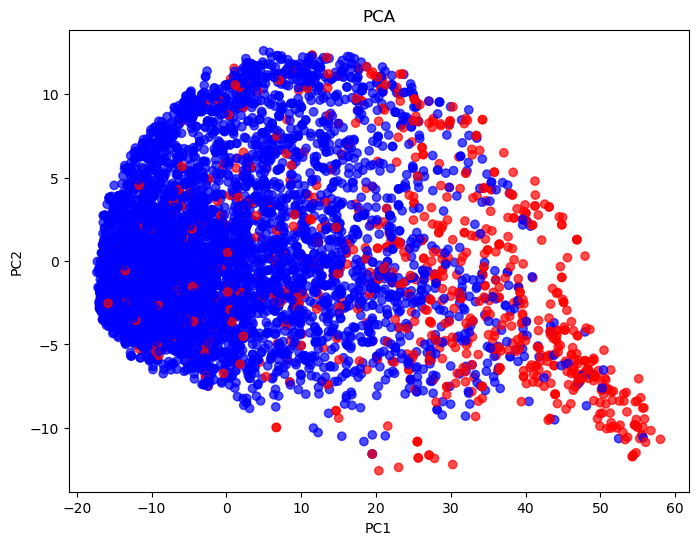

In [50]:
metrics = [
#            "euclidean",
#           "manhattan",
           "cosine"
            ]
gamma = 15.0

for metric in metrics:
    if metric == "cosine":
        aff_matrix = affinity_matrix(X, metric=metric)
    else:
        aff_matrix = affinity_matrix(X, metric=metric, gamma=gamma)

    pca = PCA()
    X_pca = pca.fit_transform(aff_matrix)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7,
#                label="Metric: {}".format(metric),
               c=train_labels, cmap="bwr")
    plt.title("PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
#    plt.grid(True)
#    plt.savefig("fine_tuned/pca_liver_train.png", dpi=400)
    plt.show()

In [51]:
metric

'cosine'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


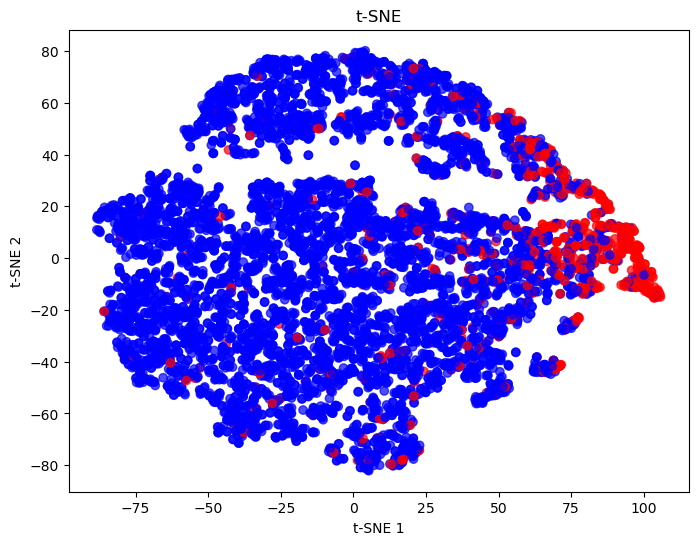

In [52]:
metrics = [
#            "euclidean",
#           "manhattan",
           "cosine"
            ]
gamma = 15.0

for metric in metrics:
    if metric == "cosine":
        aff_matrix = affinity_matrix(X, metric=metric)
    else:
        aff_matrix = affinity_matrix(X, metric=metric, gamma=gamma)

    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(aff_matrix)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.7,
                label="Metric: {}".format(metric),
               c=train_labels, cmap="bwr")
    plt.title("t-SNE")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
#    plt.savefig("fine_tuned/tsne_liver_train.png", dpi=400)

#    plt.grid(True)
    plt.show()

In [53]:
inputs = tokenizer(val_smiles, 
                   return_tensors="pt",
                   padding="max_length",
#                   max_length=512,
                   truncation=True)

inputs = {k: v.to(model.device) for k,v in inputs.items()}

In [54]:
# Prepare your input_ids and attention_mask
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# Assuming `input_ids` and `attention_mask` are your inputs prepared as PyTorch tensors
dataset = TensorDataset(input_ids, attention_mask)
batch_size = 32  # Choose a batch size that fits your GPU memory
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)  # Shuffle=False for sequential data

# Assuming embedding_extractor is your previously defined model wrapper
model.eval()  # Set the model to evaluation mode

all_embeddings = []  # To store embeddings from all batches

with torch.no_grad():  # Disables gradient calculation to save memory
    for batch_input_ids, batch_attention_mask in loader:
        # Process each batch through the model
        outputs = model.roberta(batch_input_ids, attention_mask=batch_attention_mask)

        # Access the last hidden state directly
        # This assumes you're interested in the embeddings from the last hidden state
        last_hidden_state = outputs.last_hidden_state

        # Example: Extract embeddings of the first token ([CLS] token)
        batch_embeddings = last_hidden_state[:, 0, :]  # Shape: (batch_size, hidden_size)

        # Move the extracted embeddings to CPU to save GPU memory
        all_embeddings.append(batch_embeddings.cpu())

# Concatenate all batch embeddings to get a single tensor
embeddings = torch.cat(all_embeddings, dim=0)

In [55]:
embeddings.shape

torch.Size([1905, 384])

In [56]:
val_emb = embeddings.reshape(1905, -1)
val_emb.shape

torch.Size([1905, 384])

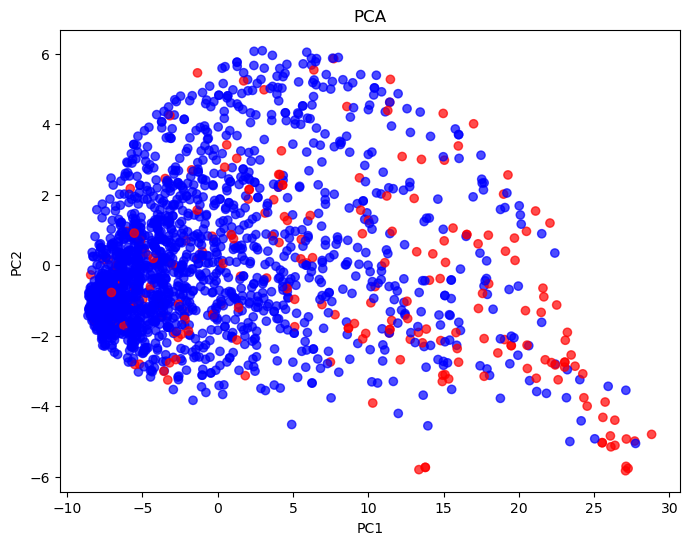

In [57]:
metrics = [
#            "euclidean",
#           "manhattan",
           "cosine"
            ]
gamma = 15.0

for metric in metrics:
    if metric == "cosine":
        aff_matrix = affinity_matrix(val_emb, metric=metric)
    else:
        aff_matrix = affinity_matrix(val_emb, metric=metric, gamma=gamma)

    pca = PCA()
    X_pca = pca.fit_transform(aff_matrix)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7,
                label="Metric: {}".format(metric),
               c=val_labels, cmap="bwr")
    plt.title("PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
#    plt.savefig("fine_tuned/pca_liver_test.png", dpi=400)
    plt.show()

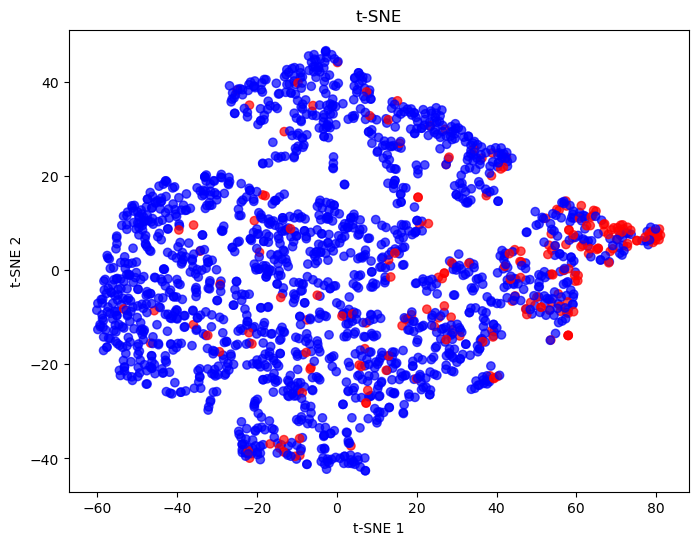

In [58]:
metrics = [
#            "euclidean",
#           "manhattan",
           "cosine"
            ]
gamma = 15.0

for metric in metrics:
    if metric == "cosine":
        aff_matrix = affinity_matrix(val_emb, metric=metric)
    else:
        aff_matrix = affinity_matrix(val_emb, metric=metric, gamma=gamma)

    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(aff_matrix)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.7,
                label="Metric: {}".format(metric),
               c=val_labels, cmap="bwr")
    plt.title("t-SNE")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
#    plt.savefig("fine_tuned/tsne_liver_test.png", dpi=400)
    plt.show()

# Now combine

In [59]:
combined_X = torch.cat((new_emb, val_emb), dim=0)

In [60]:
whole = list(train_labels)+list(val_labels)

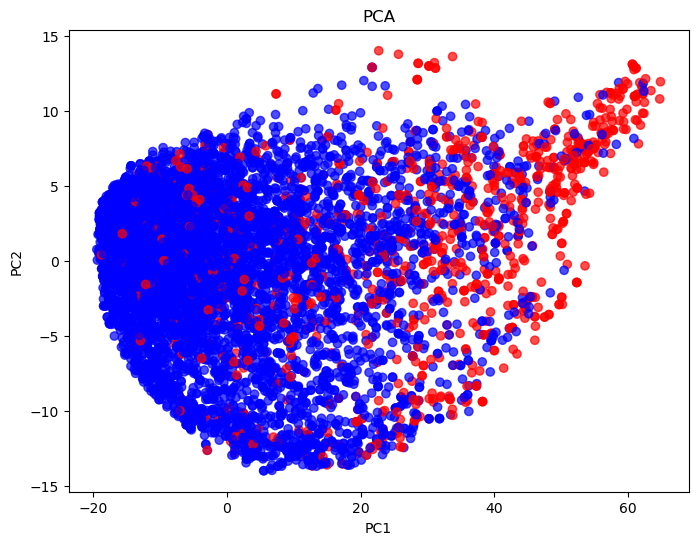

In [61]:
metrics = [
#            "euclidean",
#           "manhattan",
           "cosine"
            ]
gamma = 15.0

for metric in metrics:
    if metric == "cosine":
        aff_matrix = affinity_matrix(combined_X, metric=metric)
    else:
        aff_matrix = affinity_matrix(combined_X, metric=metric, gamma=gamma)

    pca = PCA()
    X_pca = pca.fit_transform(aff_matrix)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7,
                label="Metric: {}".format(metric),
               c=whole, cmap="bwr")
    plt.title("PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
#    plt.savefig("fine_tuned/pca_liver_all.png", dpi=400)
    plt.show()

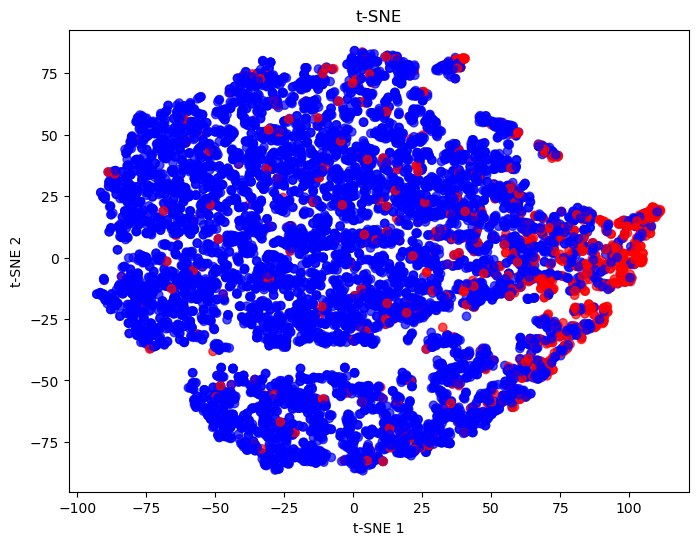

In [62]:
metrics = [
#            "euclidean",
#           "manhattan",
           "cosine"
            ]
gamma = 15.0

for metric in metrics:
    if metric == "cosine":
        aff_matrix = affinity_matrix(combined_X, metric=metric)
    else:
        aff_matrix = affinity_matrix(combined_X, metric=metric, gamma=gamma)

    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(aff_matrix)

    # Plotting
    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.7,
                label="Metric: {}".format(metric),
               c=whole, cmap="bwr")
    plt.title("t-SNE")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
#    plt.savefig("fine_tuned/tsne_liver_whole.png", dpi=400)
    plt.show()